In [17]:
import sqlite3
conn = sqlite3.connect('store.db')
cursor = conn.cursor()

الجزء 1 — JOIN: ربط الجداول ببعض

In [18]:
#كتب استعلام INNER JOIN يربط sales مع products على product_id، ويعرض: اسم المنتج، الكمية المباعة، وتاريخ البيع — لكل عملية بيع.
cursor.execute('''
select  p.product_name,
        s.quantity,
        s.sale_date
FROM  products p
INNER JOIN sales s
ON s.product_id = p.product_id
''')
result = cursor.fetchall()
print(result)

[('Laptop', 3, '2026-01-01'), ('Head Set', 10, '2026-01-15'), ('Smart Phone', 5, '2026-02-14'), ('Printer', 10, '2026-02-28'), ('Desk Chair', 6, '2026-03-01'), ('Mouse', 5, '2026-03-08'), ('USB Cable', 2, '2026-03-11'), ('Table', 1, '2026-03-15'), ('Tablet', 6, '2026-03-25'), ('Keyboard', 12, '2026-04-08'), ('Laptop', 7, '2026-04-11'), ('Mouse', 4, '2026-04-30'), ('Laptop', 3, '2026-05-01'), ('Head Set', 10, '2026-05-02'), ('Printer', 5, '2026-05-09'), ('Smart Phone', 10, '2026-05-09'), ('Head Set', 6, '2026-05-12'), ('Table', 5, '2026-05-14'), ('Keyboard', 2, '2026-05-26'), ('Laptop', 1, '2026-05-31'), ('Smart Phone', 6, '2026-06-01'), ('Smart Phone', 12, '2026-06-05'), ('Head Set', 7, '2026-06-11'), ('Mouse', 4, '2026-06-15'), ('Laptop', 3, '2026-06-28'), ('Monitor', 10, '2026-06-30'), ('Monitor', 5, '2026-07-02'), ('Smart Phone', 10, '2026-07-18'), ('Laptop', 6, '2026-07-20'), ('Keyboard', 5, '2026-07-24')]


In [19]:
#شو إجمالي الإيراد (الكمية × السعر) لكل منتج؟ 
cursor.execute('''
SELECT  products.product_name,
        SUM((sales.quantity)*(products.price))"Total Revenue"
FROM products
LEFT JOIN sales
ON products.product_id = sales.product_id
GROUP BY product_name
ORDER BY "Total Revenue" DESC 
''')
result = cursor.fetchall()
print(result)

#استخدمت LEFT JOIN منشان اشوف ايرادات كل المتجات حتى يلي ما فيها عمليات بيع تبين كمان

[('Smart Phone', 32250.0), ('Laptop', 20700.0), ('Printer', 5250.0), ('Monitor', 3000.0), ('Table', 900.0), ('Tablet', 720.0), ('Desk Chair', 720.0), ('Keyboard', 665.0), ('Head Set', 396.0), ('Mouse', 91.0), ('USB Cable', 18.0)]


In [20]:
cursor.execute('''
SELECT  p.product_name,
        p.product_id,
        p.category,
        p.price,
        s.sales_id,
        s.sale_date,
        s.quantity
FROM products p
Left JOIN sales s
ON p.product_id = s.product_id
''')
result = cursor.fetchall()
print(result)
#جميع المنتجات مباعه لا يوجد منتجات لم تباع ابدا

[('Laptop', 1, 'Electronics', 900.0, 20, '2026-05-31', 1), ('Laptop', 1, 'Electronics', 900.0, 1, '2026-01-01', 3), ('Laptop', 1, 'Electronics', 900.0, 13, '2026-05-01', 3), ('Laptop', 1, 'Electronics', 900.0, 25, '2026-06-28', 3), ('Laptop', 1, 'Electronics', 900.0, 29, '2026-07-20', 6), ('Laptop', 1, 'Electronics', 900.0, 11, '2026-04-11', 7), ('Smart Phone', 2, 'Electronics', 750.0, 3, '2026-02-14', 5), ('Smart Phone', 2, 'Electronics', 750.0, 21, '2026-06-01', 6), ('Smart Phone', 2, 'Electronics', 750.0, 16, '2026-05-09', 10), ('Smart Phone', 2, 'Electronics', 750.0, 28, '2026-07-18', 10), ('Smart Phone', 2, 'Electronics', 750.0, 22, '2026-06-05', 12), ('Mouse', 3, 'Accessories', 7.0, 12, '2026-04-30', 4), ('Mouse', 3, 'Accessories', 7.0, 24, '2026-06-15', 4), ('Mouse', 3, 'Accessories', 7.0, 6, '2026-03-08', 5), ('Head Set', 4, 'Accessories', 12.0, 17, '2026-05-12', 6), ('Head Set', 4, 'Accessories', 12.0, 23, '2026-06-11', 7), ('Head Set', 4, 'Accessories', 12.0, 2, '2026-01-15',

Inner Join  فقط المنتجات التي لها مبيعات ( المشترك بين الجدولين )
Left Join  كل المنتجات والمبيعات الموجودة , والمنتجات التي ليس لها مبيعات تظهر  NULL 
Right JOIN كل المبيعات و المنتجات المرتبطة بها 
اما عن الوضع الحالي فلم يكن هناك اي منتجات لا يوجد لها مبيعات لذلك لم تظهر اي قيمة NULL في ال  Left Join

الجزء 2 — Subqueries استعلامات متداخلة

In [21]:
# اكتب استعلام يعرض كل المنتجات يلي سعرها أعلى من متوسط سعر كل المنتجات
cursor.execute('''
SELECT product_name , price FROM products
WHERE price > ( SELECT AVG(price) FROM products) 
ORDER BY price DESC
''')
result = cursor.fetchall()
print("منتجات سعرها اعلى من متوسط الاسعار:",result)

منتجات سعرها اعلى من متوسط الاسعار: [('Laptop', 900.0), ('Smart Phone', 750.0), ('Printer', 350.0)]


In [22]:
#اكتب استعلام يعرض كل عمليات البيع يلي كميتها أعلى من متوسط الكمية بكل عمليات البيع.
cursor.execute('''
SELECT * FROM sales
WHERE quantity > (SELECT AVG(quantity) FROM sales)
ORDER BY quantity DESC
''')
result = cursor.fetchall()
print("عمليات البيع ذات الكميات الاعلى من متوسط الكميات المباعة : ",result)

عمليات البيع ذات الكميات الاعلى من متوسط الكميات المباعة :  [(10, 6, 12, 'Salt', '2026-04-08'), (22, 2, 12, 'Karak', '2026-06-05'), (2, 4, 10, 'Irbid', '2026-01-15'), (4, 5, 10, 'Salt', '2026-02-28'), (14, 4, 10, 'Tafila', '2026-05-02'), (16, 2, 10, 'Madaba', '2026-05-09'), (26, 8, 10, 'Karak', '2026-06-30'), (28, 2, 10, 'Amman', '2026-07-18'), (11, 1, 7, 'Amman', '2026-04-11'), (23, 4, 7, 'Amman', '2026-06-11')]


In [23]:
#اكتب استعلام يعرض اسم المنتج الأعلى سعرًا باستخدام Subquery بدل ORDER BY ... LIMIT 1 (جرب الطريقتين وقارن، أيهم أوضح لك؟).
cursor.execute('''
SELECT product_name FROM products
WHERE price = (SELECT MAX(price) FROM products)
''')
result = cursor.fetchall()
print("المنتج الاعلى سعرا : ",result)

# الطريقتين بنفس مستوى الوضوح الاولى كانت تقوم باعادة ترتيب المنتجات بناءا على السعر من الاعلى للأقل و ثم تخرج لنا اول اول نتيجة 
# الطريقة الثانيه تجد السعر الاعلى و من ثم تقوم باستداء المنتج صاحب هذا السعر 
# لكن في حالة الطريقه الاولى فلو كان لدينا منتجين لديهم نفس القيمه فسيستدعي لنا واحد فقط
# اما الطريق الثانيه فسيستدعي جميع المنتجات صاحبة الاعلى سعر

المنتج الاعلى سعرا :  [('Laptop',)]


الجزء 3 — Window Functions

In [24]:
#ترتيب المنتجات حسب إجمالي الإيراد (من الجزء 1) وأعطي كل منتج رقم ترتيبه
cursor.execute('''
SELECT product_name,
        Total_Revenue,
        RANK() OVER (ORDER BY Total_Revenue DESC) AS "Revenue_Rank"
FROM (
        SELECT  p.product_name,
            SUM((s.quantity)*(p.price)) AS "Total_Revenue"
        FROM products p
        LEFT JOIN sales s
        ON p.product_id = s.product_id
        GROUP BY product_name
    )
''')
result = cursor.fetchall()
print(result)

[('Smart Phone', 32250.0, 1), ('Laptop', 20700.0, 2), ('Printer', 5250.0, 3), ('Monitor', 3000.0, 4), ('Table', 900.0, 5), ('Desk Chair', 720.0, 6), ('Tablet', 720.0, 6), ('Keyboard', 665.0, 8), ('Head Set', 396.0, 9), ('Mouse', 91.0, 10), ('USB Cable', 18.0, 11)]


In [25]:
cursor.execute('''
SELECT *
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY city 
               ORDER BY quantity DESC
           ) AS row_num
    FROM sales
) 
WHERE row_num = 1
''')

result = cursor.fetchall()
print(result)


[(28, 2, 10, 'Amman', '2026-07-18', 1), (2, 4, 10, 'Irbid', '2026-01-15', 1), (22, 2, 12, 'Karak', '2026-06-05', 1), (16, 2, 10, 'Madaba', '2026-05-09', 1), (10, 6, 12, 'Salt', '2026-04-08', 1), (14, 4, 10, 'Tafila', '2026-05-02', 1)]


In [26]:
#احسب المجموع التراكمي (Running Total) للمبيعات مرتبة حسب التاريخ، باستخدام:
cursor.execute('''
SELECT
    s.sale_date,
    p.product_name,
    s.quantity,
    p.price,
    (s.quantity * p.price) AS sale_amount,
    SUM(s.quantity * p.price) OVER (ORDER BY s.sale_date) AS running_total
FROM sales s
JOIN products p
ON s.product_id = p.product_id
ORDER BY s.sale_date;
''')
result = cursor.fetchall()
print(result)


[('2026-01-01', 'Laptop', 3, 900.0, 2700.0, 2700.0), ('2026-01-15', 'Head Set', 10, 12.0, 120.0, 2820.0), ('2026-02-14', 'Smart Phone', 5, 750.0, 3750.0, 6570.0), ('2026-02-28', 'Printer', 10, 350.0, 3500.0, 10070.0), ('2026-03-01', 'Desk Chair', 6, 120.0, 720.0, 10790.0), ('2026-03-08', 'Mouse', 5, 7.0, 35.0, 10825.0), ('2026-03-11', 'USB Cable', 2, 9.0, 18.0, 10843.0), ('2026-03-15', 'Table', 1, 150.0, 150.0, 10993.0), ('2026-03-25', 'Tablet', 6, 120.0, 720.0, 11713.0), ('2026-04-08', 'Keyboard', 12, 35.0, 420.0, 12133.0), ('2026-04-11', 'Laptop', 7, 900.0, 6300.0, 18433.0), ('2026-04-30', 'Mouse', 4, 7.0, 28.0, 18461.0), ('2026-05-01', 'Laptop', 3, 900.0, 2700.0, 21161.0), ('2026-05-02', 'Head Set', 10, 12.0, 120.0, 21281.0), ('2026-05-09', 'Printer', 5, 350.0, 1750.0, 30531.0), ('2026-05-09', 'Smart Phone', 10, 750.0, 7500.0, 30531.0), ('2026-05-12', 'Head Set', 6, 12.0, 72.0, 30603.0), ('2026-05-14', 'Table', 5, 150.0, 750.0, 31353.0), ('2026-05-26', 'Keyboard', 2, 35.0, 70.0, 314

GROUP BY  بتجمع مجموعة من الصفوف بصف واحد بالتالي بتقل عدد الصفوف 
WINDOW FUNCTION  بتجري الحسابات على مجموعة صفوف لكن تضيف أعمدة محسوبة على البيانات و بتحافظ على عدد الصفوف

الجزء 4 — الدمج مع Pandas

In [27]:
import pandas as pd
query = '''
SELECT  products.product_name,
        SUM((sales.quantity)*(products.price))"Total Revenue"
FROM products
LEFT JOIN sales
ON products.product_id = sales.product_id
GROUP BY product_name
ORDER BY "Total Revenue" DESC LIMIT 5
'''
total_revenue = pd.read_sql_query(query,conn)
print (total_revenue)


  product_name  Total Revenue
0  Smart Phone        32250.0
1       Laptop        20700.0
2      Printer         5250.0
3      Monitor         3000.0
4        Table          900.0


In [28]:
import plotly.express as px
fig_1 = px.bar(total_revenue,x="product_name",y="Total Revenue",title = "Products Total Revenue",color = "product_name"
                ,labels = {"product_name":"Product Name"})
fig_1.write_html("Products Total Revenue Chart.html")
fig_1.show()

In [29]:
query_2 = '''SELECT
    s.sale_date,
    p.product_name,
    s.quantity,
    p.price,
    (s.quantity * p.price) AS sale_amount,
    SUM(s.quantity * p.price) OVER (ORDER BY s.sale_date) AS running_total
FROM sales s
JOIN products p
ON s.product_id = p.product_id
ORDER BY s.sale_date
'''
sales_amount_trend= pd.read_sql_query(query_2,conn)
print(sales_amount_trend)

     sale_date product_name  quantity  price  sale_amount  running_total
0   2026-01-01       Laptop         3  900.0       2700.0         2700.0
1   2026-01-15     Head Set        10   12.0        120.0         2820.0
2   2026-02-14  Smart Phone         5  750.0       3750.0         6570.0
3   2026-02-28      Printer        10  350.0       3500.0        10070.0
4   2026-03-01   Desk Chair         6  120.0        720.0        10790.0
5   2026-03-08        Mouse         5    7.0         35.0        10825.0
6   2026-03-11    USB Cable         2    9.0         18.0        10843.0
7   2026-03-15        Table         1  150.0        150.0        10993.0
8   2026-03-25       Tablet         6  120.0        720.0        11713.0
9   2026-04-08     Keyboard        12   35.0        420.0        12133.0
10  2026-04-11       Laptop         7  900.0       6300.0        18433.0
11  2026-04-30        Mouse         4    7.0         28.0        18461.0
12  2026-05-01       Laptop         3  900.0       

In [30]:
fig_2 = px.line(sales_amount_trend,x="sale_date",y="running_total",title="Cumulative Sales Revenue Over Time",
                labels={"sale_date": "Sale Date","running_total": "Cumulative Revenue"})
fig_2.write_html("cumulative_sales_revenue.html")
fig_2.show()

In [33]:
query_3 = '''SELECT
    city,
    product_name,
    total_revenue,
    RANK() OVER (
        PARTITION BY city
        ORDER BY total_revenue DESC
    ) AS revenue_rank
FROM (
    SELECT
        s.city,
        p.product_name,
        SUM(s.quantity * p.price) AS total_revenue
    FROM sales s
    JOIN products p
    ON s.product_id = p.product_id
    GROUP BY s.city, p.product_name
)ORDER BY city, revenue_rank'''
city_revenue_rank = pd.read_sql_query(query_3,conn)
print(city_revenue_rank)

      city product_name  total_revenue  revenue_rank
0    Amman       Laptop         9000.0             1
1    Amman  Smart Phone         7500.0             2
2    Amman   Desk Chair          720.0             3
3    Amman     Keyboard          175.0             4
4    Amman     Head Set           84.0             5
5    Amman        Mouse           56.0             6
6    Irbid        Table          900.0             1
7    Irbid     Head Set          120.0             2
8    Irbid     Keyboard           70.0             3
9    Karak  Smart Phone        13500.0             1
10   Karak      Monitor         2000.0             2
11   Karak        Mouse           35.0             3
12   Karak    USB Cable           18.0             4
13  Madaba  Smart Phone         7500.0             1
14  Madaba      Printer         1750.0             2
15  Madaba      Monitor         1000.0             3
16    Salt       Laptop         6300.0             1
17    Salt      Printer         3500.0        

In [38]:
fig = px.bar(city_revenue_rank,x="city",y="total_revenue",color="product_name",
    barmode="group",title="Product Revenue Ranking by City",
    labels={"city": "City","total_revenue": "Total Revenue","product_name": "Product"})

fig.write_html("product_revenue_by_city.html")
fig.show()

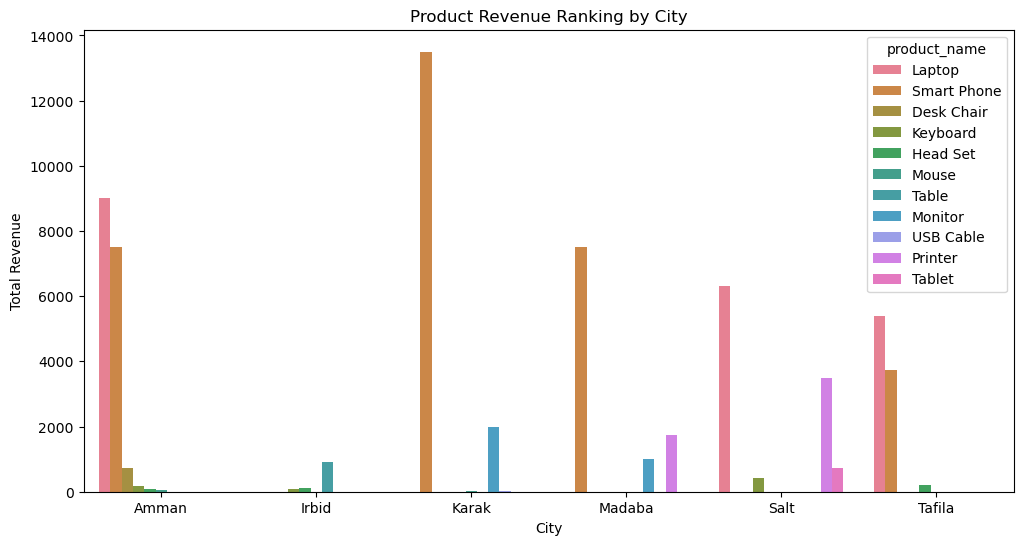

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(data=city_revenue_rank,x="city",y="total_revenue",hue="product_name")

plt.title("Product Revenue Ranking by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")

plt.show()

يوضح التحليل أن ترتيب المنتجات حسب الإيراد يختلف من مدينة إلى أخرى، مما يعكس اختلاف سلوك الشراء وتفضيلات العملاء بين المناطق الجغرافية. يمكن الاستفادة من هذه الرؤية في تطوير استراتيجيات تسويقية وبيعية مخصصة لكل منطقة، مثل توجيه الحملات الإعلانية والتركيز على المنتجات الأكثر طلبًا في كل مدينة